# QuadraticRNN on Discrete $SE(2)$, $\mathbb{Z}_n^2 \rtimes C_m$

**Group:** $\mathbb{Z}_n^2 \rtimes C_m$ — translations and rotations on a discrete lattice (order $mn^2$), where $m \in \{1, 2, 3, 4, 6\}$ (crystallographic restriction).  
**Semidirect product:** $(x_1, y_1, r_1) \cdot (x_2, y_2, r_2) = ((x_1, y_1) + A^{r_1}(x_2, y_2) \bmod n,\; r_1 + r_2 \bmod m)$.  
**Task:** Given encodings of two group elements $g_1, g_2$, predict $g_1 \cdot g_2$.  
**Sequence length:** $k = 2$ (binary composition).  
**Architecture:** `QuadraticRNN` with Adam optimizer.  
**MLP baseline:** see `src/configs/config_discrete_se2_mlp.yaml` for the equivalent `TwoLayerMLP` run.


## Set up

### Imports


In [34]:
%load_ext autoreload
%autoreload 2

import os
import random

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from src.groups import DiscreteSE2Group
import src.dataset as dataset
import src.model as model
import src.optimizer as optimizer
import src.template as template
import src.train as train_mod
import src.viz as viz

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Specify Device

In [35]:
device_name = "cuda:0"  # change to "cpu" if no GPU

if device_name.startswith("cuda") and not torch.cuda.is_available():
    print("Warning: CUDA not available, falling back to CPU")
    device = torch.device("cpu")
else:
    device = torch.device(device_name)

print(f"Using device: {device}")

Using device: cuda:0


### Configuration


In [36]:
TEST_MODE = os.environ.get("NOTEBOOK_TEST_MODE", "0") == "1"
SAVE_FIGS = False

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed);

## Group & Irreps

### Instantiate Group $G = \mathbb{Z}_n^2 \rtimes C_m$

In [37]:
n = 10  # order of translation subgroup
m = 3  # rotation order: one of {1, 2, 3, 4, 6}
group = DiscreteSE2Group(n=n, m=m)
group_size = group.order


group_label = f"Z_{n}^2 ⋊ C_{m}"
group_label_latex = f"$\\mathbb{{Z}}_{{{n}}}^2 \\rtimes C_{{{m}}}$"
file_tag = f"discrete_se2_n{n}_m{m}_rnn"
print(f"Group: {group_label}, order {group_size}")

Group: Z_10^2 ⋊ C_3, order 300


### List all $C_m$-orbits of characters of $G$:

In [38]:
orbit_dict = group.orbit_dict()
orbit_dict

{1: [[(0, 0)]],
 3: [[(0, 1), (9, 9), (1, 0)],
  [(0, 2), (8, 8), (2, 0)],
  [(0, 3), (7, 7), (3, 0)],
  [(0, 4), (6, 6), (4, 0)],
  [(0, 5), (5, 5), (5, 0)],
  [(0, 6), (4, 4), (6, 0)],
  [(0, 7), (3, 3), (7, 0)],
  [(0, 8), (2, 2), (8, 0)],
  [(0, 9), (1, 1), (9, 0)],
  [(1, 2), (8, 9), (1, 9)],
  [(1, 3), (7, 8), (2, 9)],
  [(1, 4), (6, 7), (3, 9)],
  [(1, 5), (5, 6), (4, 9)],
  [(1, 6), (4, 5), (5, 9)],
  [(1, 7), (3, 4), (6, 9)],
  [(1, 8), (2, 3), (7, 9)],
  [(2, 1), (9, 1), (9, 8)],
  [(2, 4), (6, 8), (2, 8)],
  [(2, 5), (5, 7), (3, 8)],
  [(2, 6), (4, 6), (4, 8)],
  [(2, 7), (3, 5), (5, 8)],
  [(3, 1), (9, 2), (8, 7)],
  [(3, 2), (8, 1), (9, 7)],
  [(3, 6), (4, 7), (3, 7)],
  [(4, 1), (9, 3), (7, 6)],
  [(4, 2), (8, 2), (8, 6)],
  [(4, 3), (7, 1), (9, 6)],
  [(5, 1), (9, 4), (6, 5)],
  [(5, 2), (8, 3), (7, 5)],
  [(5, 3), (7, 2), (8, 5)],
  [(5, 4), (6, 1), (9, 5)],
  [(6, 2), (8, 4), (6, 4)],
  [(6, 3), (7, 3), (7, 4)]]}

### List all irreps of $G$:

In [39]:
irreps = group.irreps()
irreps

[IrreducibleRepresentation(name='ZnZnCm_n10_m3|1d_orb0_s0', dim=1),
 IrreducibleRepresentation(name='ZnZnCm_n10_m3|1d_orb0_s1', dim=1),
 IrreducibleRepresentation(name='ZnZnCm_n10_m3|1d_orb0_s2', dim=1),
 IrreducibleRepresentation(name='ZnZnCm_n10_m3|3d_orb0_s0', dim=3),
 IrreducibleRepresentation(name='ZnZnCm_n10_m3|3d_orb1_s0', dim=3),
 IrreducibleRepresentation(name='ZnZnCm_n10_m3|3d_orb2_s0', dim=3),
 IrreducibleRepresentation(name='ZnZnCm_n10_m3|3d_orb3_s0', dim=3),
 IrreducibleRepresentation(name='ZnZnCm_n10_m3|3d_orb4_s0', dim=3),
 IrreducibleRepresentation(name='ZnZnCm_n10_m3|3d_orb5_s0', dim=3),
 IrreducibleRepresentation(name='ZnZnCm_n10_m3|3d_orb6_s0', dim=3),
 IrreducibleRepresentation(name='ZnZnCm_n10_m3|3d_orb7_s0', dim=3),
 IrreducibleRepresentation(name='ZnZnCm_n10_m3|3d_orb8_s0', dim=3),
 IrreducibleRepresentation(name='ZnZnCm_n10_m3|3d_orb9_s0', dim=3),
 IrreducibleRepresentation(name='ZnZnCm_n10_m3|3d_orb10_s0', dim=3),
 IrreducibleRepresentation(name='ZnZnCm_n10_m3|

In [41]:
print(len(irreps))

36


### List all pairs of conjugate irreps (singleton if an irrep is self-conjugate):

In [40]:
conjugate_pairs = group.conjugate_pairs()
conjugate_pairs

[[0],
 [1, 2],
 [3, 11],
 [4, 10],
 [5, 9],
 [6, 8],
 [7],
 [12, 19],
 [13, 25],
 [14, 29],
 [15, 33],
 [16, 30],
 [17, 27],
 [18, 24],
 [20, 28],
 [21, 32],
 [22, 34],
 [23, 31],
 [26, 35]]

## Template and Dataset

In [42]:
n_irreps = len(irreps)

# 1. Pick a power for each pair (the only thing you actually choose).
pair_powers = {1: 1.0, 2: 0.5, 3: 0.25}        # pair_index -> power; absent => 0

# 2. Broadcast to per-irrep, automatically respecting conjugacy.
powers = np.zeros(n_irreps)
for pair_idx, pair in enumerate(conjugate_pairs):
    p = pair_powers.get(pair_idx, 0.0)
    for ir in pair:
        powers[ir] = p

tpl = template.custom_fourier(group, powers)     # guaranteed real

In [46]:
tpl = template.one_hot(group.order)

### Visualize template

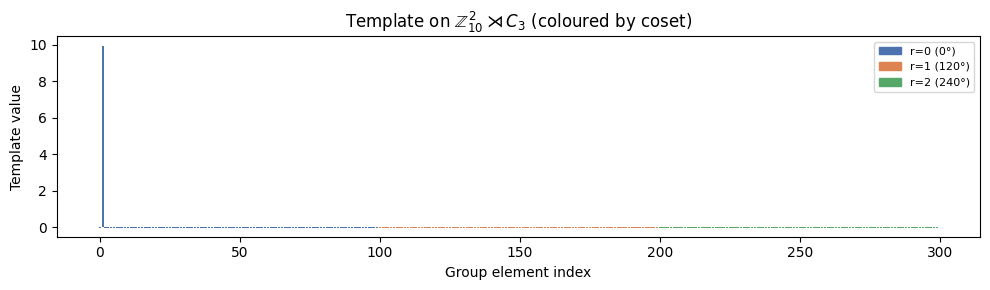

In [47]:
ROTATION_ANGLES = {1: [0], 2: [0, 180], 3: [0, 120, 240], 4: [0, 90, 180, 270], 6: [0, 60, 120, 180, 240, 300]}
angles = ROTATION_ANGLES[m]

_palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']
colors = _palette[:m]
coset_labels = [f"r={r} ({angles[r]}°)" for r in range(m)]
bar_colors = [colors[idx // (n * n)] for idx in range(group_size)]

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(group_size), tpl, color=bar_colors)
ax.set_xlabel("Group element index")
ax.set_ylabel("Template value")
ax.set_title(f"Template on {group_label_latex} (coloured by coset)")

patches = [mpatches.Patch(color=colors[i], label=coset_labels[i]) for i in range(m)]
ax.legend(handles=patches, fontsize=8)
plt.tight_layout()

if SAVE_FIGS:
    plt.savefig(f"{FIGURES_DIR}/{file_tag}_template.pdf", bbox_inches="tight")
plt.show()

### Create Dataset

In [48]:
pair_ds = dataset.GroupCompositionDataset(
    group,
    template=tpl,
    k=2,
    mode="exhaustive",
)

X_tensor = pair_ds.X.to(device)
Y_tensor = pair_ds.Y.to(device)

ds = TensorDataset(X_tensor, Y_tensor)
dataloader = DataLoader(ds, batch_size=len(ds), shuffle=False)

print(f"Dataset: {len(ds)} samples ({group_size}x{group_size} exhaustive pairs)")
print(f"X shape: {X_tensor.shape}, Y shape: {Y_tensor.shape}")

Dataset: 90000 samples (300x300 exhaustive pairs)
X shape: torch.Size([90000, 2, 300]), Y shape: torch.Size([90000, 300])


In [49]:
def fmt(b):
    for unit in ("B", "KiB", "MiB", "GiB", "TiB"):
        if b < 1024:
            return f"{b:.2f} {unit}"
        b /= 1024
    return f"{b:.2f} PiB"

# Post hoc — use real shapes
def tensor_bytes(t):
    return t.element_size() * t.nelement()

ds_bytes    = tensor_bytes(pair_ds.X) + tensor_bytes(pair_ds.Y)
batch_bytes = ds_bytes / max(1, len(dataloader))   # or = ds_bytes if batch_size=len(ds)
print(f"Dataset on {device}: {fmt(ds_bytes)}  "
      f"({len(ds)} samples, X={tuple(pair_ds.X.shape)}, Y={tuple(pair_ds.Y.shape)})")
print(f"Per batch         : {fmt(batch_bytes)}  (n_batches={len(dataloader)})")

Dataset on cuda:0: 308.99 MiB  (90000 samples, X=(90000, 2, 300), Y=(90000, 300))
Per batch         : 308.99 MiB  (n_batches=1)


In [51]:
def estimate_dataset_bytes(group_size, k, mode="exhaustive", num_samples=None, dtype_bytes=4):
    N = group_size ** k if mode == "exhaustive" else int(num_samples)
    x_bytes = N * k * group_size * dtype_bytes
    y_bytes = N *     group_size * dtype_bytes
    return N, x_bytes + y_bytes, x_bytes, y_bytes

N, total, xb, yb = estimate_dataset_bytes(group_size, k=3, mode="exhaustive")
print(f"N={N:,}, total={fmt(total)}  (X={fmt(xb)}, Y={fmt(yb)})")

N=27,000,000, total=120.70 GiB  (X=90.52 GiB, Y=30.17 GiB)


## Model and Loss function


In [52]:
hidden_dim = 50 if TEST_MODE else 3000
init_scale = 5e-2

net = model.QuadraticRNN(
    group_size=group_size,
    hidden_dim=hidden_dim,
    k=2,
    init_scale=init_scale,
    return_all_outputs=False,
)
net = net.to(device)

criterion = nn.MSELoss()


total_params = sum(p.nelement() for p in net.parameters())
mb_per_snap = sum(p.nelement() * p.element_size() for p in net.parameters()) / 1024**2
print(f"Model: QuadraticRNN(group_size={group_size}, hidden_dim={hidden_dim}, k=2)")
print(f"Number of parameters: {total_params:,}")
print(f"MB per snapshot: {mb_per_snap:.2f}")

Model: QuadraticRNN(group_size=300, hidden_dim=3000, k=2)
Number of parameters: 11,700,000
MB per snapshot: 44.63


## Optimizer

In [53]:
learning_rate = 1e-3
opt = torch.optim.Adam(net.parameters(), lr=learning_rate)

#opt = optimizer.PerNeuronScaledSGD(net, lr=lr)
#print(f"Optimizer: PerNeuronScaledSGD(lr={lr}, degree={opt.param_groups[0]['degree']})")

## Training


In [54]:
# save_param_interval controls how often weights are snapshotted.
# Reduce this or set save_param_snapshots=False to save memory.

epochs = 2 if TEST_MODE else 500

save_interval = 1 if TEST_MODE else max(1, epochs // 100)

loss_history, val_loss_history, param_history, param_save_epochs, final_epoch = train_mod.train(
    net,
    dataloader,
    criterion,
    opt,
    epochs=epochs,
    verbose_interval=max(1, epochs // 10),
    grad_clip=0.1,
    save_param_interval=save_interval,
)

print(f"Finished at epoch {final_epoch}. Snapshots stored: {len(param_history)}")

[Epoch    50 (seg    50/500)] loss: 0.332222 | reduction:    0.0%
[Epoch   100 (seg   100/500)] loss: 0.332222 | reduction:    0.0%
[Epoch   150 (seg   150/500)] loss: 0.332181 | reduction:    0.0%
[Epoch   200 (seg   200/500)] loss: 0.221168 | reduction:   33.4%
[Epoch   250 (seg   250/500)] loss: 0.118838 | reduction:   64.2%
[Epoch   300 (seg   300/500)] loss: 0.078438 | reduction:   76.4%
[Epoch   350 (seg   350/500)] loss: 0.040824 | reduction:   87.7%
[Epoch   400 (seg   400/500)] loss: 0.027400 | reduction:   91.8%
[Epoch   450 (seg   450/500)] loss: 0.023552 | reduction:   92.9%
[Epoch   500 (seg   500/500)] loss: 0.023766 | reduction:   92.8%
Finished at epoch 500. Snapshots stored: 101


## Training Loss


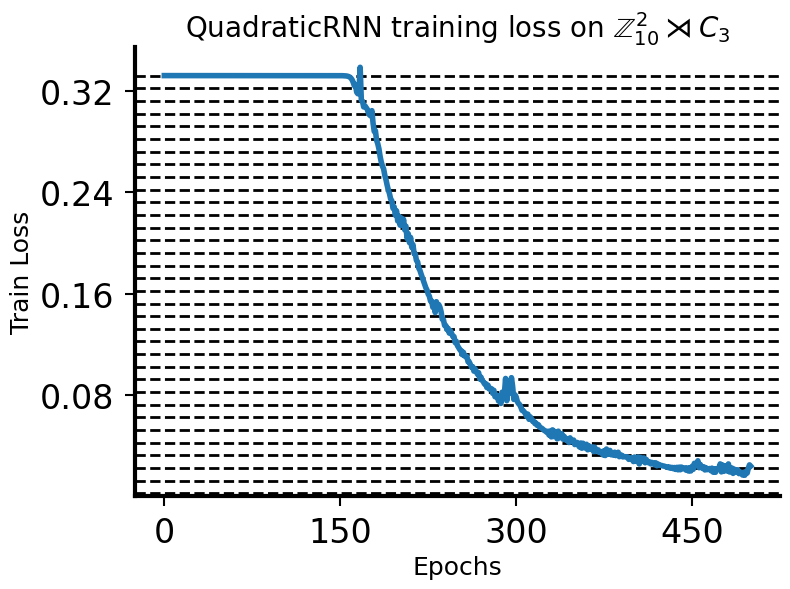

In [55]:
theory_levels = viz.loss_plateau_predictions(tpl, group)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(loss_history, lw=4)

for level in theory_levels[:-1]:
    ax.axhline(y=level, color="black", linestyle="--", linewidth=2, zorder=-2)

#ax.set_xscale("log")
ax.set_xlabel("Epochs", fontsize=18)
ax.set_ylabel("Train Loss", fontsize=18)
ax.set_title(f"QuadraticRNN training loss on {group_label_latex}", fontsize=20)
viz.style_axes(ax)
ax.grid(False)
plt.tight_layout()

if SAVE_FIGS:
    plt.savefig(f"{FIGURES_DIR}/{file_tag}_loss.pdf", bbox_inches="tight")
plt.show()

## Power Spectrum Over Training

### Compute power spectrum over training

In [56]:
powers_over_time, power_steps = viz.model_power_over_time(
    group,
    model=net,
    param_history=param_history,
    model_inputs=X_tensor,
)

template_pwr = group.power_spectrum(tpl)

Computing power at step 1 with output shape (1800, 300)
Computing power at step 56 with output shape (1800, 300)
Computing power at step 66 with output shape (1800, 300)
Computing power at step 76 with output shape (1800, 300)


KeyboardInterrupt: 

### Visualize power spectrum over training

<unknown>:171: SyntaxWarning: invalid escape sequence '\s'
<unknown>:171: SyntaxWarning: invalid escape sequence '\s'


IndexError: index 11 is out of bounds for axis 1 with size 11

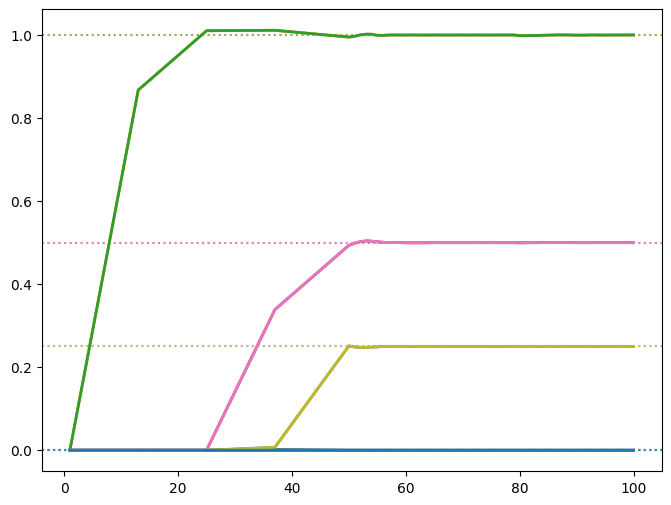

In [57]:
tab_colors = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(8, 6))

for k in range(n_irreps):
    color = tab_colors[k % len(tab_colors)]
    ax.plot(power_steps, powers_over_time[:, k], color=color, lw=2,
            label=f"irrep {k} (d={irreps[k].dim})")
    ax.axhline(template_pwr[k], color=color, linestyle="dotted", linewidth=1.5,
               alpha=0.5, zorder=-10)

#ax.set_xscale("log")
ax.set_ylabel("Power", fontsize=18)
ax.set_xlabel("Epochs", fontsize=18)
ax.set_title(f"Power spectrum over training on {group_label_latex}", fontsize=20)
ax.legend(fontsize=8, title="Irrep", title_fontsize=10, loc="upper left", labelspacing=0.25)
viz.style_axes(ax)
ax.grid(False)
plt.tight_layout()

if SAVE_FIGS:
    plt.savefig(f"{FIGURES_DIR}/{file_tag}_power_spectrum.pdf", bbox_inches="tight")
plt.show()

In [17]:
nonzero_mask = template_pwr > 1e-10
template_pwr_zeroed = [np.round(template_pwr[i], 3) if nonzero_mask[i] else 0 for i in range(n_irreps)]

print(template_pwr_zeroed)

[0, 1.0, 1.0, 0.5, 0.25, 0, 0.5, 0, 0.25, 0, 0]


## Irreducible Representations


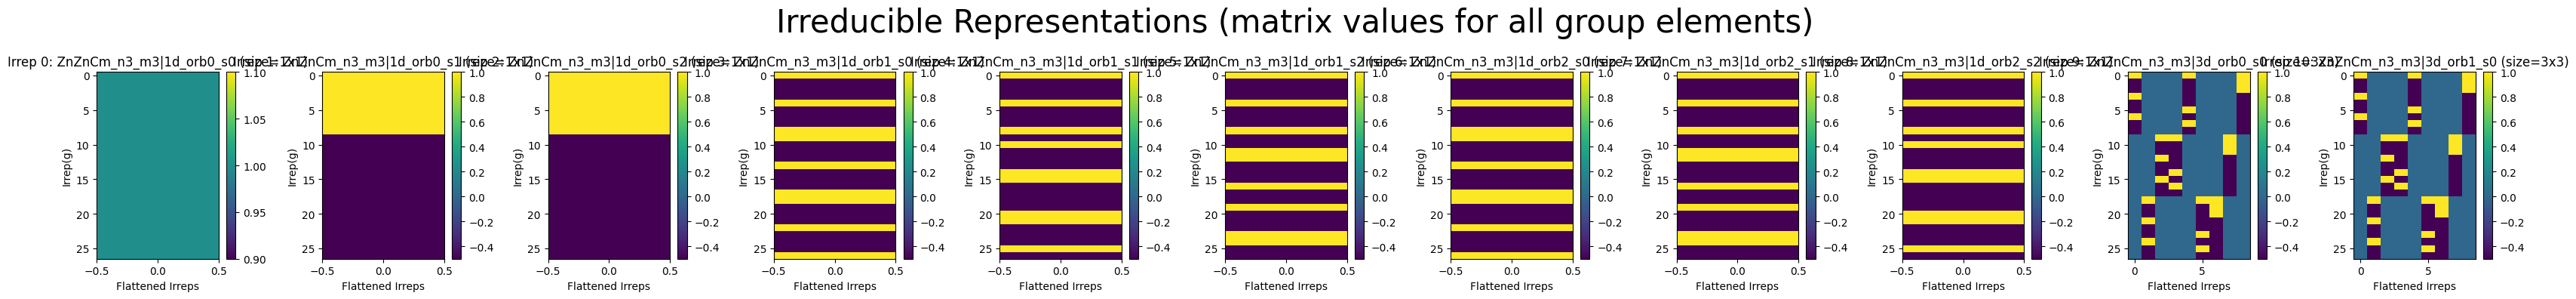

In [18]:
fig = viz.plot_irreps(group, show=False)

if SAVE_FIGS:
    plt.savefig(f"{FIGURES_DIR}/{file_tag}_irreps.pdf", bbox_inches="tight")
plt.show()

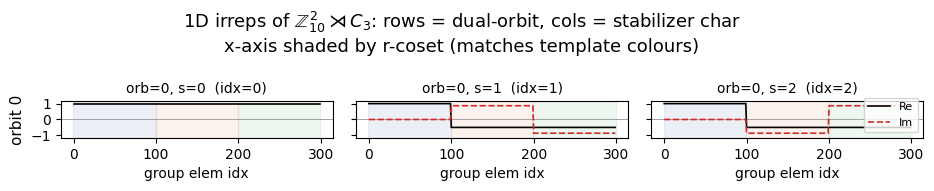

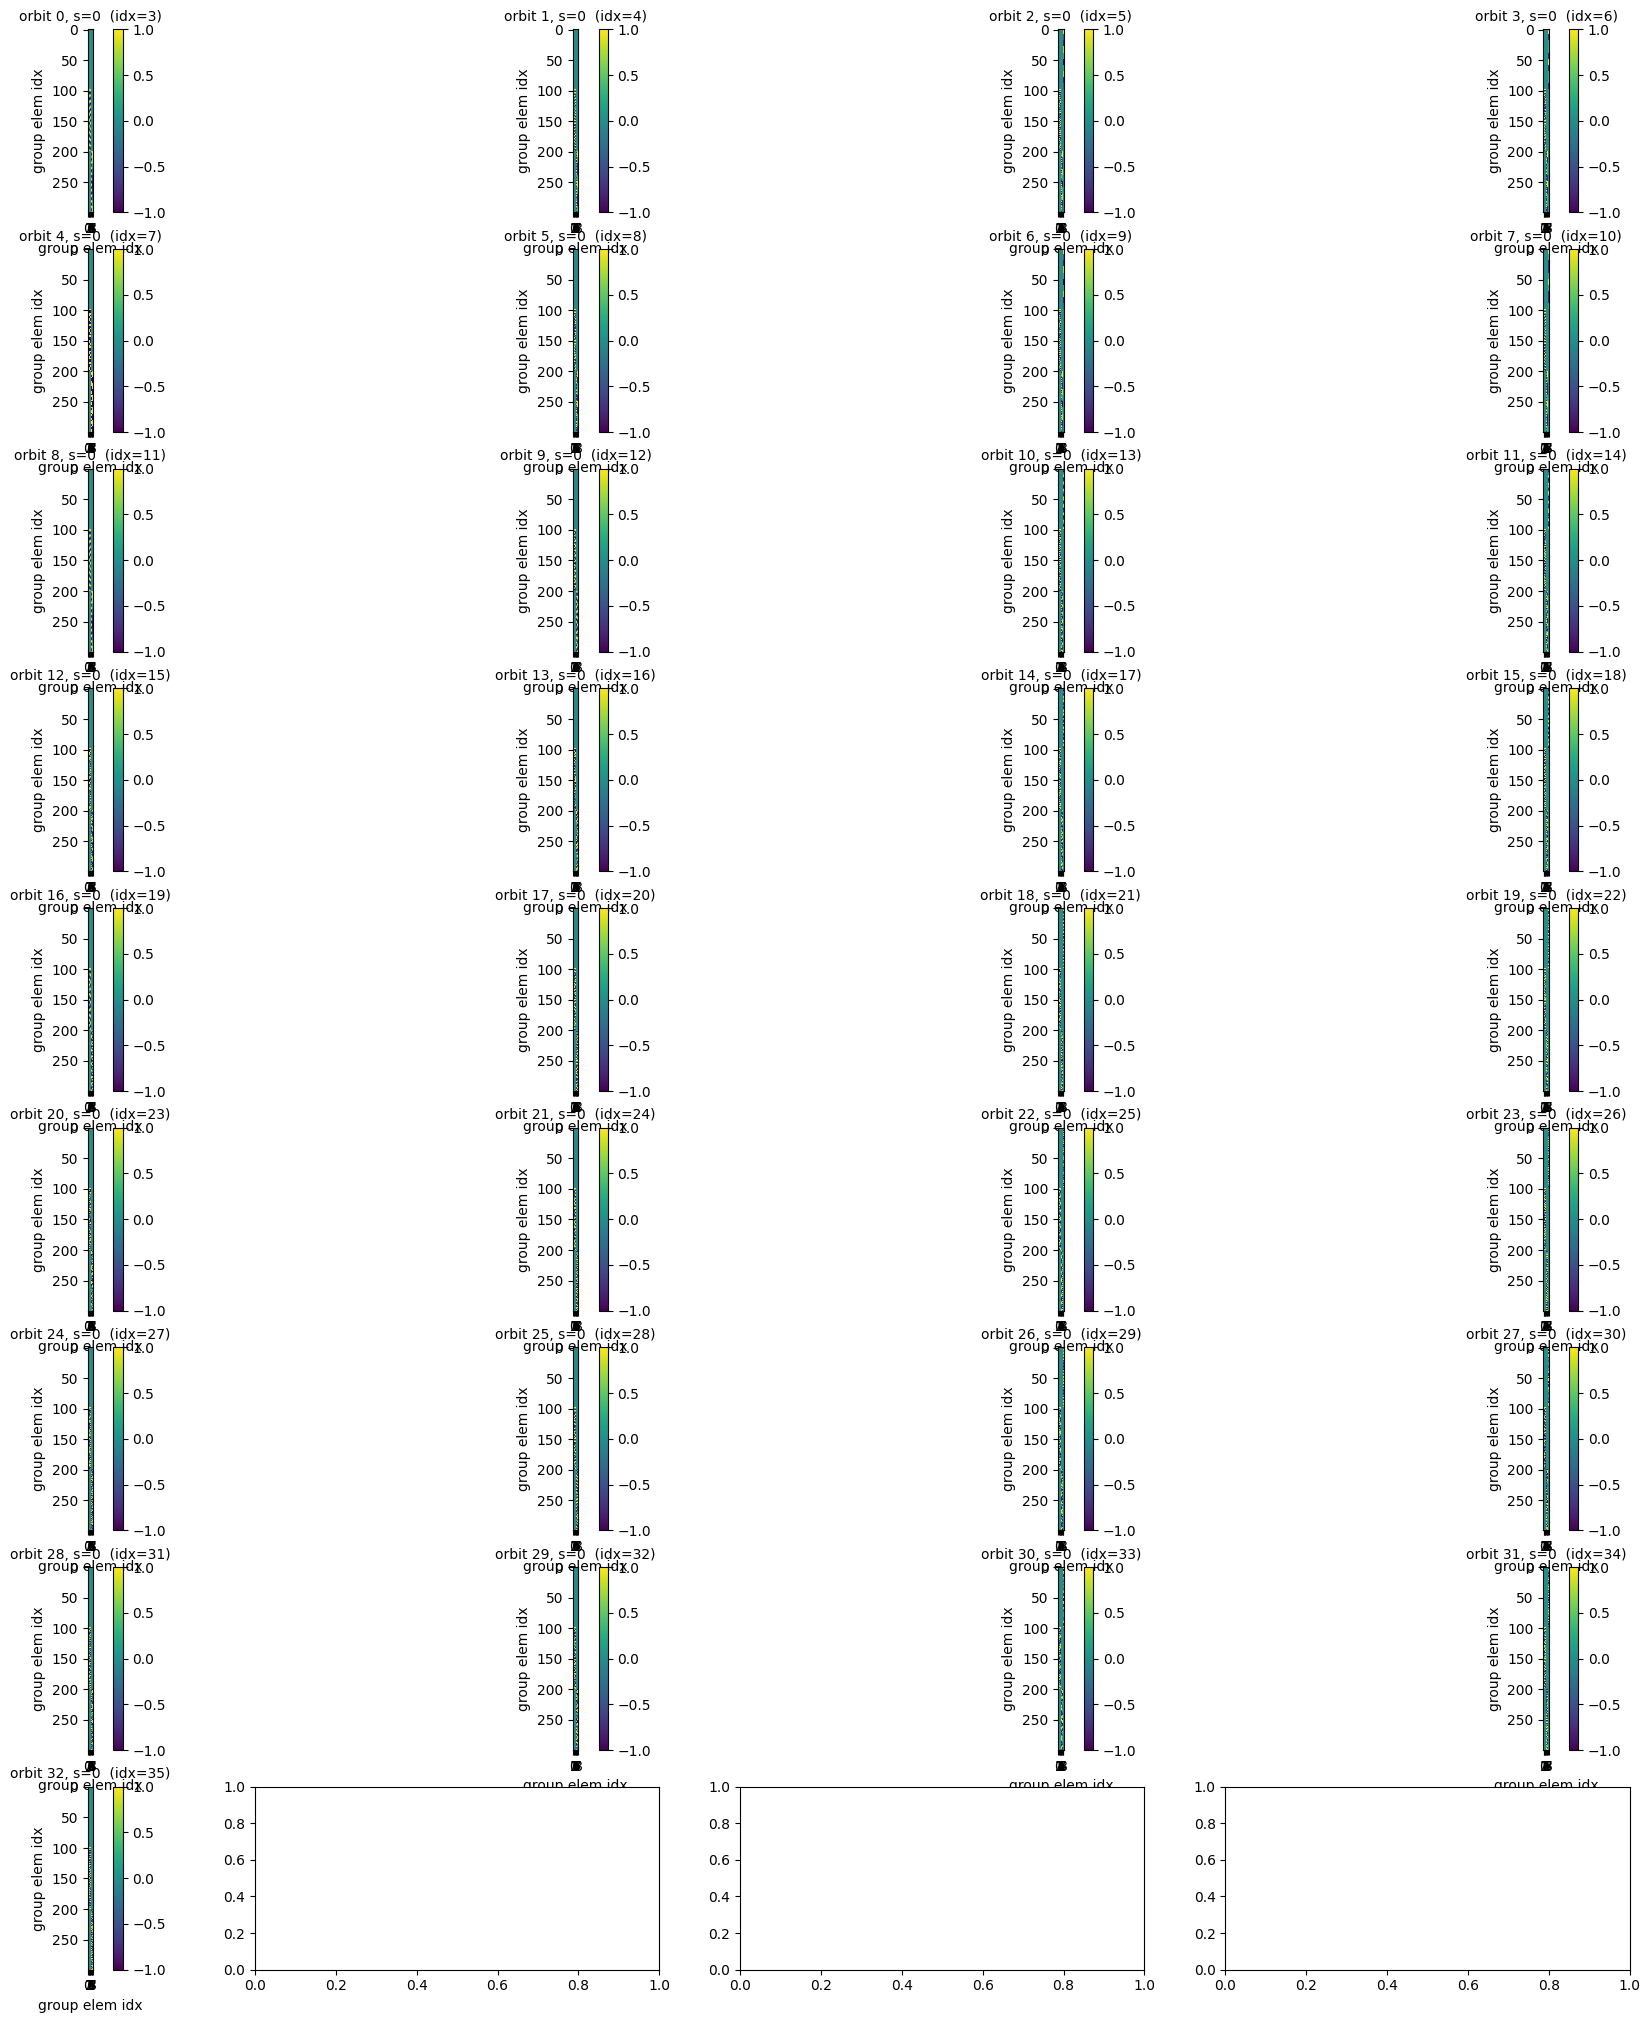

In [58]:
import re
from collections import defaultdict

SAVE_FIGS = globals().get("SAVE_FIGS", True)  # respect upstream flag if set

group_elements = group.elements()
n_elem = len(group_elements)


def _parse_orb_s(ir, idx):
    """Extract (orb_idx, s) from irrep name; fall back to (idx, 0)."""
    name = getattr(ir, "_name", "") or ""
    m_ = re.search(r"orb(\d+)_s(\d+)", name)
    if m_:
        return int(m_.group(1)), int(m_.group(2))
    return idx, 0


# by_dim[d][orb] = [(s, irrep_idx), ...]
by_dim = defaultdict(lambda: defaultdict(list))
for i, ir in enumerate(irreps):
    orb, s_ = _parse_orb_s(ir, i)
    by_dim[ir.dim][orb].append((s_, i))


def shade_cosets(ax):
    for r in range(m):
        ax.axvspan(
            r * n * n - 0.5,
            (r + 1) * n * n - 0.5,
            color=colors[r],
            alpha=0.10,
            zorder=-10,
        )


# === 1D irreps: rows = dual-orbit, cols = stabilizer character ===
if 1 in by_dim:
    orbits_1d = sorted(by_dim[1].keys())
    n_orb_1d = len(orbits_1d)
    n_s_1d = max(len(by_dim[1][o]) for o in orbits_1d)

    fig1, axes1 = plt.subplots(
        n_orb_1d, n_s_1d,
        figsize=(3.2 * n_s_1d, 1.9 * n_orb_1d),
        squeeze=False, sharex=True, sharey=True,
    )
    for r_idx, orb in enumerate(orbits_1d):
        entries = sorted(by_dim[1][orb])
        for c_idx in range(n_s_1d):
            ax = axes1[r_idx, c_idx]
            if c_idx >= len(entries):
                ax.axis("off")
                continue
            s_, i = entries[c_idx]
            vals = np.array([irreps[i](g) for g in group_elements]).reshape(-1)
            shade_cosets(ax)
            ax.plot(vals.real, lw=1.2, color="k", label="Re")
            if np.any(np.abs(vals.imag) > 1e-10):
                ax.plot(vals.imag, lw=1.2, color="C3", ls="--", label="Im")
            ax.axhline(0, color="grey", lw=0.5, zorder=-5)
            ax.set_title(f"orb={orb}, s={s_}  (idx={i})", fontsize=10)
            ax.set_ylim(-1.15, 1.15)
            if r_idx == n_orb_1d - 1:
                ax.set_xlabel("group elem idx")
            if c_idx == 0:
                ax.set_ylabel(f"orbit {orb}", fontsize=11)
            if r_idx == 0 and c_idx == n_s_1d - 1:
                ax.legend(loc="lower right", fontsize=8)
    fig1.suptitle(
        f"1D irreps of {group_label_latex}: rows = dual-orbit, cols = stabilizer char\n"
        f"x-axis shaded by r-coset (matches template colours)",
        fontsize=13,
    )
    fig1.tight_layout()
    if SAVE_FIGS:
        plt.savefig(f"{FIGURES_DIR}/{file_tag}_irreps_1d.pdf", bbox_inches="tight")
    plt.show()

# === Multi-D irreps: one heatmap per (orbit, s), tiled in a grid ===
multi_dims = sorted(d for d in by_dim if d > 1)
for d in multi_dims:
    entries = []
    for orb in sorted(by_dim[d].keys()):
        for s_, i in sorted(by_dim[d][orb]):
            entries.append((orb, s_, i))
    n_panels = len(entries)
    ncols = min(4, n_panels)
    nrows = int(np.ceil(n_panels / ncols))

    fig2, axes2 = plt.subplots(
        nrows, ncols,
        figsize=(6.0 * ncols, 2.8 * nrows),
        squeeze=False,
    )
    flat_axes = axes2.flatten()
    im = None
    for p_idx, (orb, s_, i) in enumerate(entries):
        ax = flat_axes[p_idx]
        mats = np.array([irreps[i](g) for g in group_elements])  # (|G|, d, d)
        flat = mats.real.reshape(n_elem, d * d)
        im = ax.imshow(
            flat, aspect="equal", cmap="viridis",
            vmin=-1, vmax=1, interpolation="None",
        )
        ax.set_xlabel("group elem idx")
        ax.set_ylabel(f"group elem idx")
        ax.set_title(f"orbit {orb}, s={s_}  (idx={i})", fontsize=10)
        ax.set_xticks(range(d * d))
        plt.colorbar(im, ax=ax)

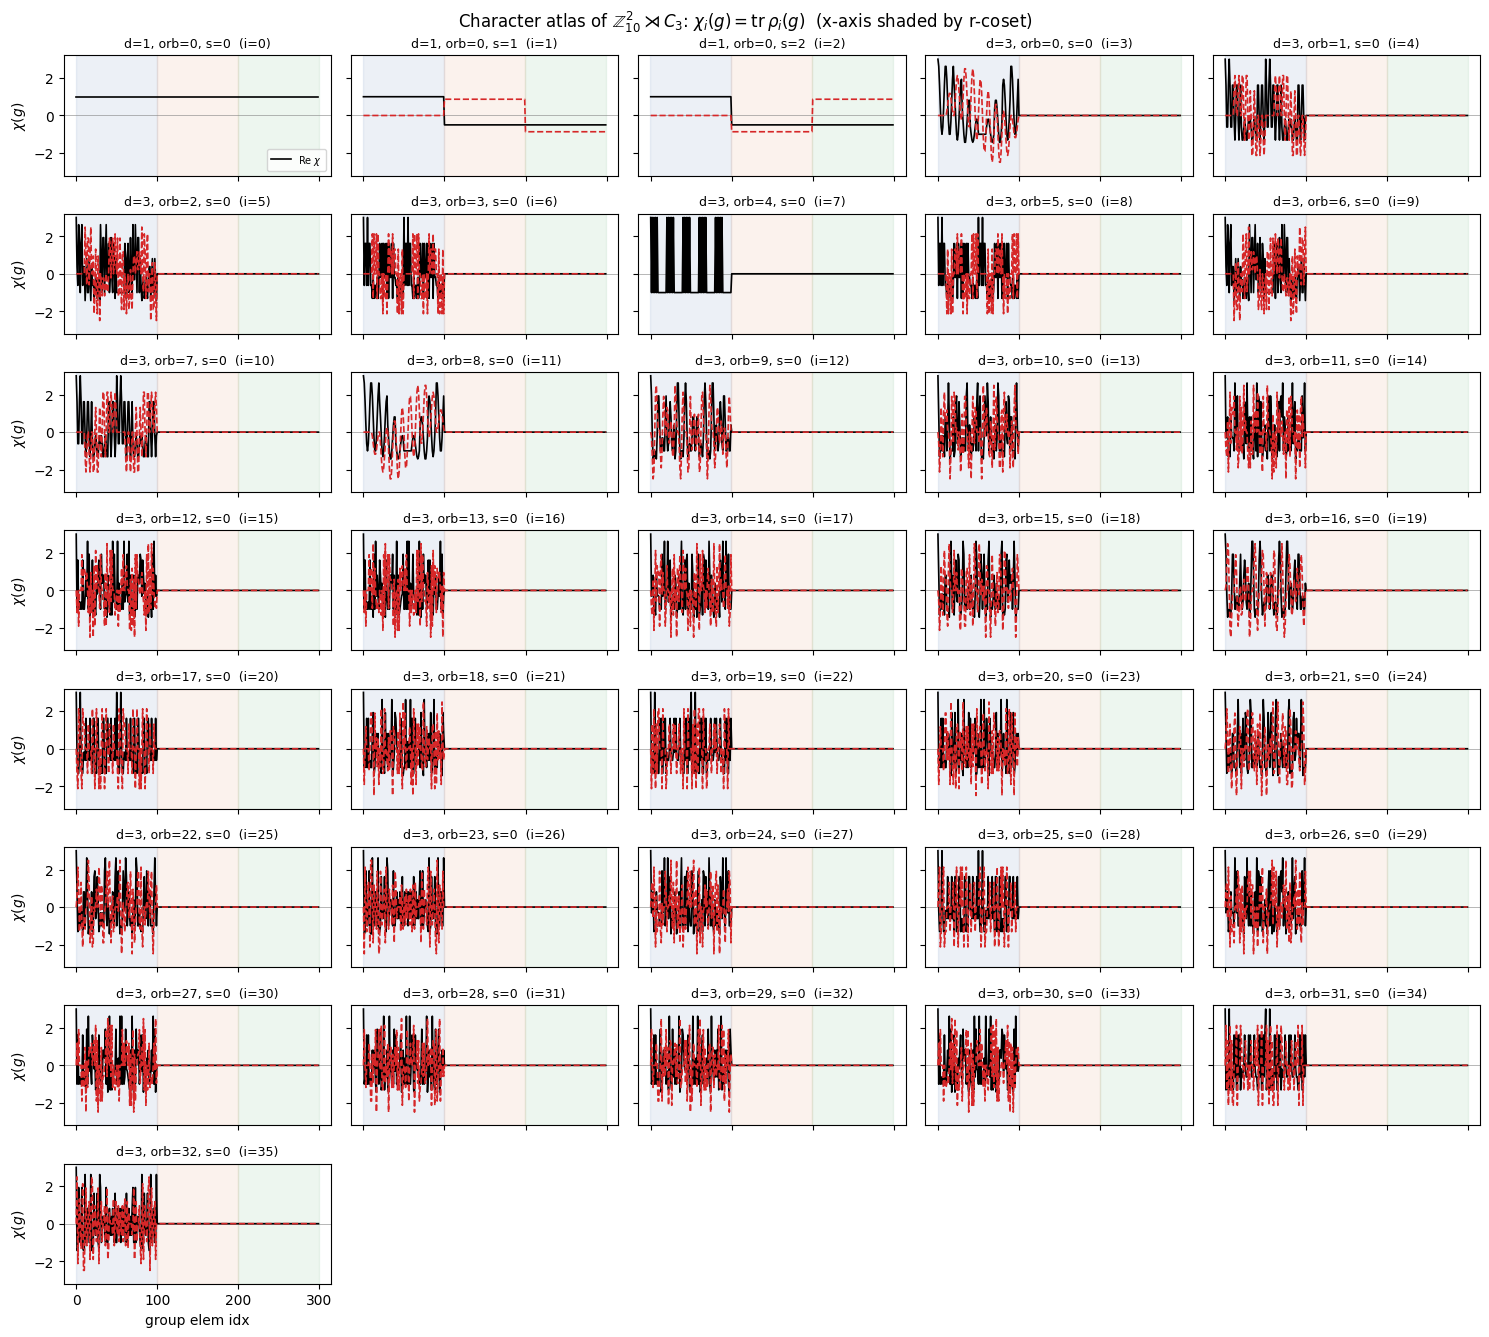

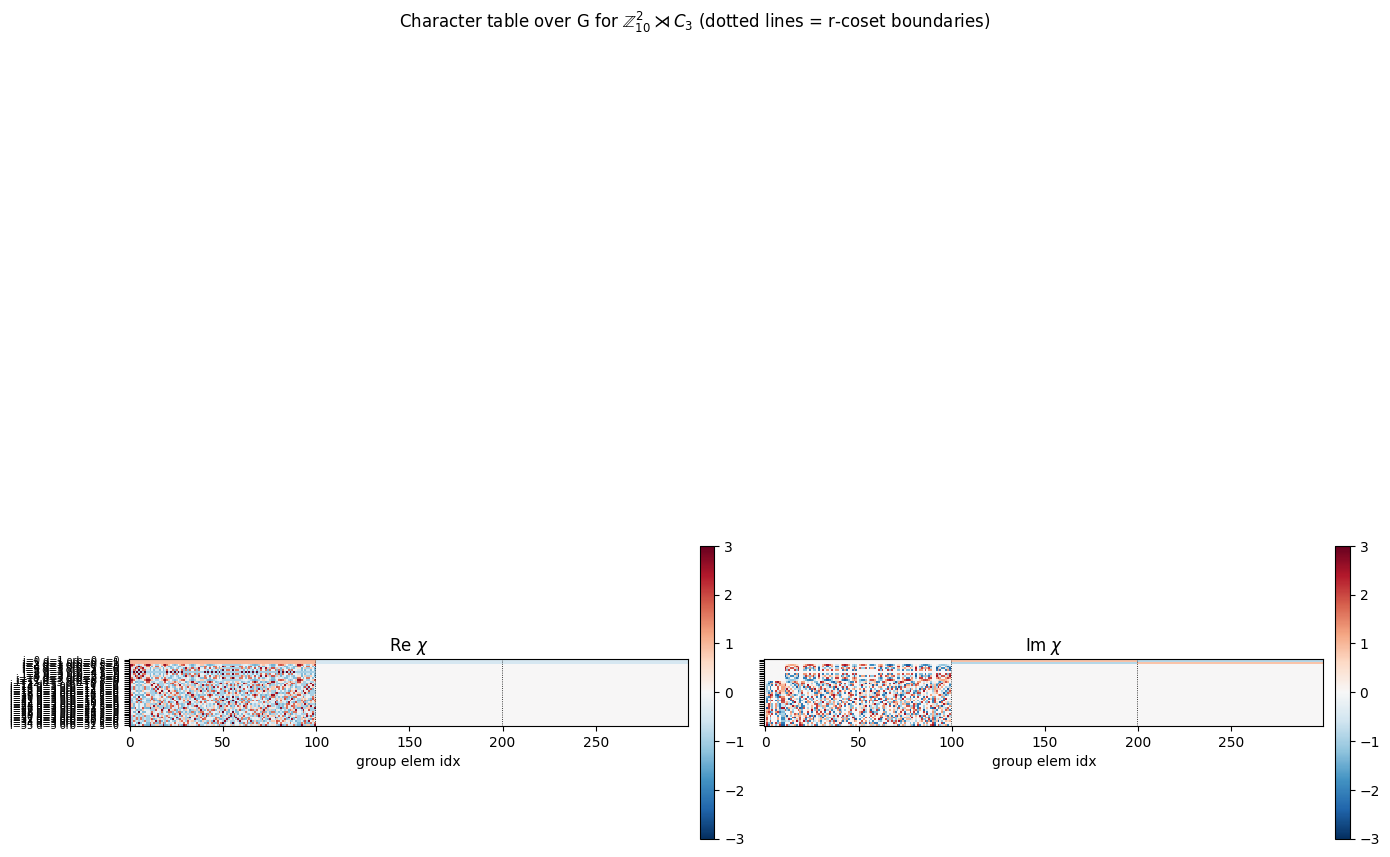

In [59]:
import re
from collections import defaultdict

SAVE_FIGS = globals().get("SAVE_FIGS", True)

irreps_list = group.irreps()
group_elements = group.elements()
n_elem = len(group_elements)


def _parse_orb_s(ir, idx):
    name = getattr(ir, "_name", "") or ""
    m_ = re.search(r"orb(\d+)_s(\d+)", name)
    return (int(m_.group(1)), int(m_.group(2))) if m_ else (idx, 0)


# Compute all characters: chi[i, g] = trace(rho_i(g)), complex
chars = np.zeros((len(irreps_list), n_elem), dtype=np.complex128)
labels = []
for i, ir in enumerate(irreps_list):
    orb, s_ = _parse_orb_s(ir, i)
    labels.append((ir.dim, orb, s_, i))
    for g in group_elements:
        M = np.atleast_2d(ir(g))
        chars[i, g] = np.trace(M)

# Sort irreps by (dim, orb, s) so families sit together
order = sorted(range(len(irreps_list)), key=lambda i: labels[i])
chars = chars[order]
labels = [labels[i] for i in order]
d_max = max(lbl[0] for lbl in labels)


def shade_cosets(ax, alpha=0.10):
    for r in range(m):
        ax.axvspan(r * n * n - 0.5, (r + 1) * n * n - 0.5,
                   color=colors[r], alpha=alpha, zorder=-10)


# === Layer 1: character atlas (one panel per irrep, fully consistent) ===
n_ir = len(irreps_list)
ncols = 5
nrows = int(np.ceil(n_ir / ncols))
fig1, axes1 = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 1.7 * nrows),
                           squeeze=False, sharex=True, sharey=True)
for p, ax in enumerate(axes1.flat):
    if p >= n_ir:
        ax.axis("off")
        continue
    d, orb, s_, orig_i = labels[p]
    chi = chars[p]
    shade_cosets(ax)
    ax.plot(chi.real, lw=1.2, color="k", label=r"Re $\chi$")
    if np.any(np.abs(chi.imag) > 1e-10):
        ax.plot(chi.imag, lw=1.2, color="C3", ls="--", label=r"Im $\chi$")
    ax.axhline(0, color="grey", lw=0.4, zorder=-5)
    ax.set_title(f"d={d}, orb={orb}, s={s_}  (i={orig_i})", fontsize=9)
    ax.set_ylim(-d_max - 0.2, d_max + 0.2)
    if p % ncols == 0:
        ax.set_ylabel(r"$\chi(g)$")
    if p // ncols == nrows - 1:
        ax.set_xlabel("group elem idx")
axes1.flat[0].legend(loc="lower right", fontsize=7)
fig1.suptitle(
    f"Character atlas of {group_label_latex}: $\\chi_i(g)=\\mathrm{{tr}}\\,\\rho_i(g)$  "
    f"(x-axis shaded by r-coset)",
    fontsize=12,
)
fig1.tight_layout()
if SAVE_FIGS:
    plt.savefig(f"{FIGURES_DIR}/{file_tag}_char_atlas.pdf", bbox_inches="tight")
plt.show()


# === Layer 2: one-shot heatmap (rows = irreps, cols = group elements) ===
ytick_labels = [f"i={oi} d={d} orb={orb} s={s_}" for d, orb, s_, oi in labels]
fig2, (ax_re, ax_im) = plt.subplots(1, 2, figsize=(14, 0.35 * n_ir + 1.2),
                                    sharey=True)
vmax = float(np.max(np.abs(chars)))
for ax, data, name in [(ax_re, chars.real, "Re $\\chi$"),
                       (ax_im, chars.imag, "Im $\\chi$")]:
    im = ax.imshow(data, aspect="equal", cmap="RdBu_r",
                   vmin=-vmax, vmax=vmax, interpolation="None")
    for r in range(1, m):
        ax.axvline(r * n * n - 0.5, color="black", lw=0.6, ls=":")
    ax.set_title(name)
    ax.set_xlabel("group elem idx")
    fig2.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
ax_re.set_yticks(range(n_ir))
ax_re.set_yticklabels(ytick_labels, fontsize=7)
fig2.suptitle(f"Character table over G for {group_label_latex} "
              f"(dotted lines = r-coset boundaries)", fontsize=12)
fig2.tight_layout()
if SAVE_FIGS:
    plt.savefig(f"{FIGURES_DIR}/{file_tag}_char_heatmap.pdf", bbox_inches="tight")
plt.show()

## Output Weights — Grid Overview


### Extract readout weights

In [60]:
t = -1 # last epoch
param = "W_out" # readout weights

W_all = param_history[t][param].detach().cpu().numpy()
n_group_elements, n_neurons = W_all.shape
print(f"n_group_elements: {n_group_elements}, n_neurons: {n_neurons}")

n_group_elements: 300, n_neurons: 3000


### Average readout weights over rotations:

In [61]:
rows, cols = 10, 10
max_neurons_to_show = min(rows * cols, n_neurons)

images = []
for idx in range(max_neurons_to_show):
    w = W_all[:, idx]
    w_averaged_over_rotations = w.reshape(m, n, n).sum(axis=0)
    images.append(w_averaged_over_rotations)

### Visualize readout weights (averaged over rotations)

/tmp/ipykernel_2269343/3568312830.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


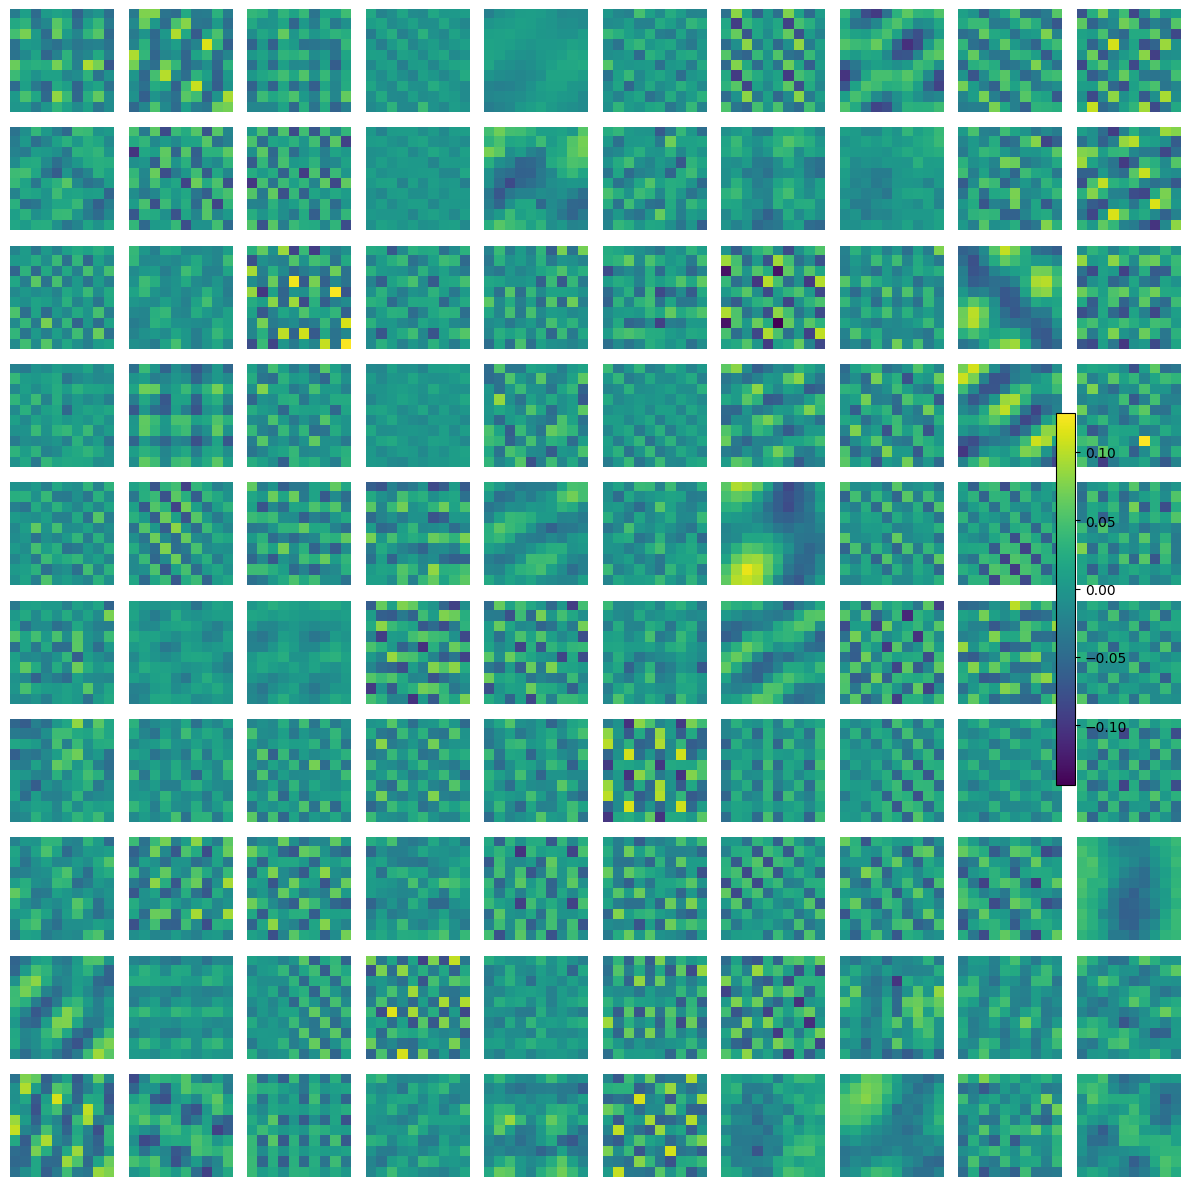

In [62]:
vmin = min(img.min() for img in images)
vmax = max(img.max() for img in images)
norm = Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
axes = np.asarray(axes).reshape(rows, cols)
im = None
for k, ax in enumerate(axes.flat):
    if k < len(images):
        im = ax.imshow(images[k], cmap="viridis", norm=norm)
    ax.axis("off")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01)
plt.tight_layout()

if SAVE_FIGS:
    plt.savefig(f"{FIGURES_DIR}/{file_tag}_weights_grid.pdf", bbox_inches="tight")
plt.show()

## Output Weights Analysis


### Helper functions

In [63]:
# === Setup: shared helpers + dominant-irrep bucketing ===
K_MAX = 8                                              # max neurons shown per irrep row
elems = group.elements()


def neuron_rot_marg(w):
    """sum_r w(x,y,r) -> shape (n, n)."""
    return w.reshape(m, n, n).sum(axis=0)


def neuron_trans_marg(w):
    """sum_{x,y} w(x,y,r) -> shape (m,)."""
    return w.reshape(m, n, n).sum(axis=(1, 2))


def _irrep_full(irrep):
    """Stack rho_i(g) over g in G; promote scalars to (1,1,1) so .real / shape works uniformly."""
    M = np.array([irrep(g) for g in elems])
    if M.ndim == 1:
        M = M[:, None, None]
    return M  # (|G|, d, d)


def theory_rot_marg(irrep):
    M = _irrep_full(irrep)               # (|G|, d, d)
    chi = np.trace(M, axis1=-2, axis2=-1)  # (|G|,)  basis-invariant
    return chi.real.reshape(m, n, n).sum(axis=0)  # (n, n)


def theory_trans_marg(irrep):
    M = _irrep_full(irrep)
    chi = np.trace(M, axis1=-2, axis2=-1)
    return chi.real.reshape(m, n, n).sum(axis=(1, 2))  # (m,)


# def theory_rot_marg(irrep):
#     """sum_r sum_{a,b} Re rho_i(x,y,r)_{ab} -> (n, n).
#     NOTE: this picture is only nonzero for the C_m-trivial part of the irrep
#     (stabilizer char s=0). For s != 0 the row will be ~0 (and so will real neurons
#     aligned with that irrep, after rotation-marginalization)."""
#     M = _irrep_full(irrep)
#     d = M.shape[1]
#     return M.real.reshape(m, n, n, d, d).sum(axis=0).sum(axis=(-1, -2))


# def theory_trans_marg(irrep):
#     """sum_{x,y} sum_{a,b} Re rho_i(x,y,r)_{ab} -> (m,).
#     NOTE: only nonzero for irreps in the trivial dual orbit (a=b=0) — usually
#     just the m irreps with orb=0. Other rows will be ~0."""
#     M = _irrep_full(irrep)
#     d = M.shape[1]
#     return M.real.reshape(m, n, n, d, d).sum(axis=(1, 2)).sum(axis=(-1, -2))

### Assign neurons to dominant irrep

In [64]:
# Per-neuron quantities (computed ONCE; both display cells reuse these)
neuron_imgs = np.stack([neuron_rot_marg(W_all[:, k])  for k in range(n_neurons)])  # (H, n, n)
neuron_vecs = np.stack([neuron_trans_marg(W_all[:, k]) for k in range(n_neurons)]) # (H, m)

# Dominant irrep + power, then top-K bucket per irrep
ps = np.stack([group.power_spectrum(W_all[:, k]) for k in range(n_neurons)])       # (H, n_irreps)
dom = ps.argmax(axis=1)                                                            # (H,)
power_at_dom = ps[np.arange(n_neurons), dom]                                       # (H,)
neurons_by_irrep = {
    gid: np.where(dom == gid)[0][np.argsort(-power_at_dom[dom == gid])][:K_MAX].tolist()
    for gid in range(len(irreps))
}
counts = {gid: int((dom == gid).sum()) for gid in range(len(irreps))}

### Rotation-marginal display

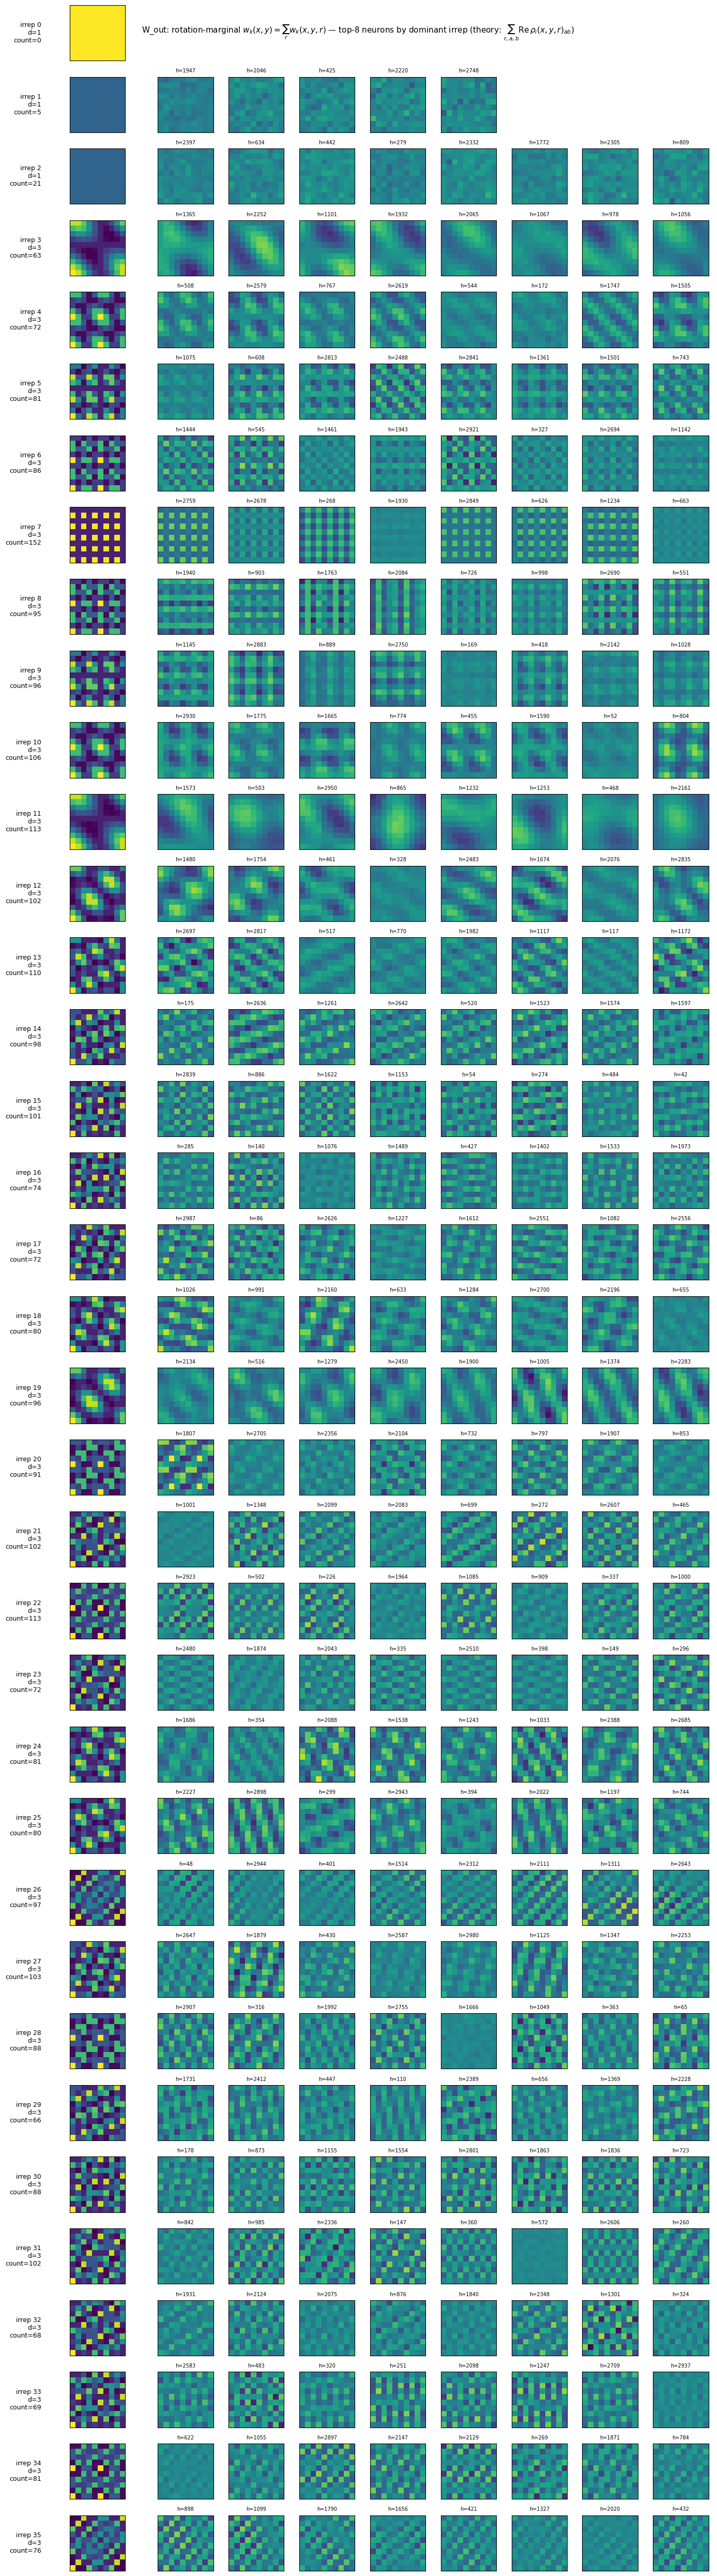

In [65]:
# === Rotation-marginal display (replaces the broken cell) ===
theory_imgs = [theory_rot_marg(ir) for ir in irreps]
norm_n  = Normalize(vmin=neuron_imgs.min(), vmax=neuron_imgs.max())
norm_th = Normalize(vmin=min(t.min() for t in theory_imgs),
                    vmax=max(t.max() for t in theory_imgs))

nrows = len(irreps)
ncols = 2 + K_MAX
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(1.4 * ncols, 1.4 * nrows),
    squeeze=False,
    gridspec_kw={"width_ratios": [1.0, 0.15] + [1.0] * K_MAX},
)
for r, gid in enumerate(range(len(irreps))):
    ax_th = axes[r, 0]
    ax_th.imshow(theory_imgs[gid], cmap="viridis", norm=norm_th, origin="lower")
    ax_th.set_xticks([]); ax_th.set_yticks([])
    ax_th.set_ylabel(f"irrep {gid}\nd={irreps[gid].dim}\ncount={counts[gid]}",
                     rotation=0, ha="right", va="center", labelpad=40, fontsize=9)
    axes[r, 1].axis("off")
    bucket = neurons_by_irrep[gid]
    for c in range(K_MAX):
        ax = axes[r, c + 2]
        if c < len(bucket):
            k = bucket[c]
            ax.imshow(neuron_imgs[k], cmap="viridis", norm=norm_n, origin="lower")
            ax.set_title(f"h={k}", fontsize=7)
            ax.set_xticks([]); ax.set_yticks([])
        else:
            ax.axis("off")
fig.suptitle(
    rf"{param}: rotation-marginal $w_k(x,y) = \sum_r w_k(x,y,r)$ — top-{K_MAX} neurons by dominant irrep "
    rf"(theory: $\sum_{{r,a,b}}\mathrm{{Re}}\,\rho_i(x,y,r)_{{ab}}$)",
    fontsize=11,
)
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(f"{FIGURES_DIR}/{file_tag}_weights_by_irrep_rot.pdf", bbox_inches="tight")
plt.show()

### Translation-marginal display

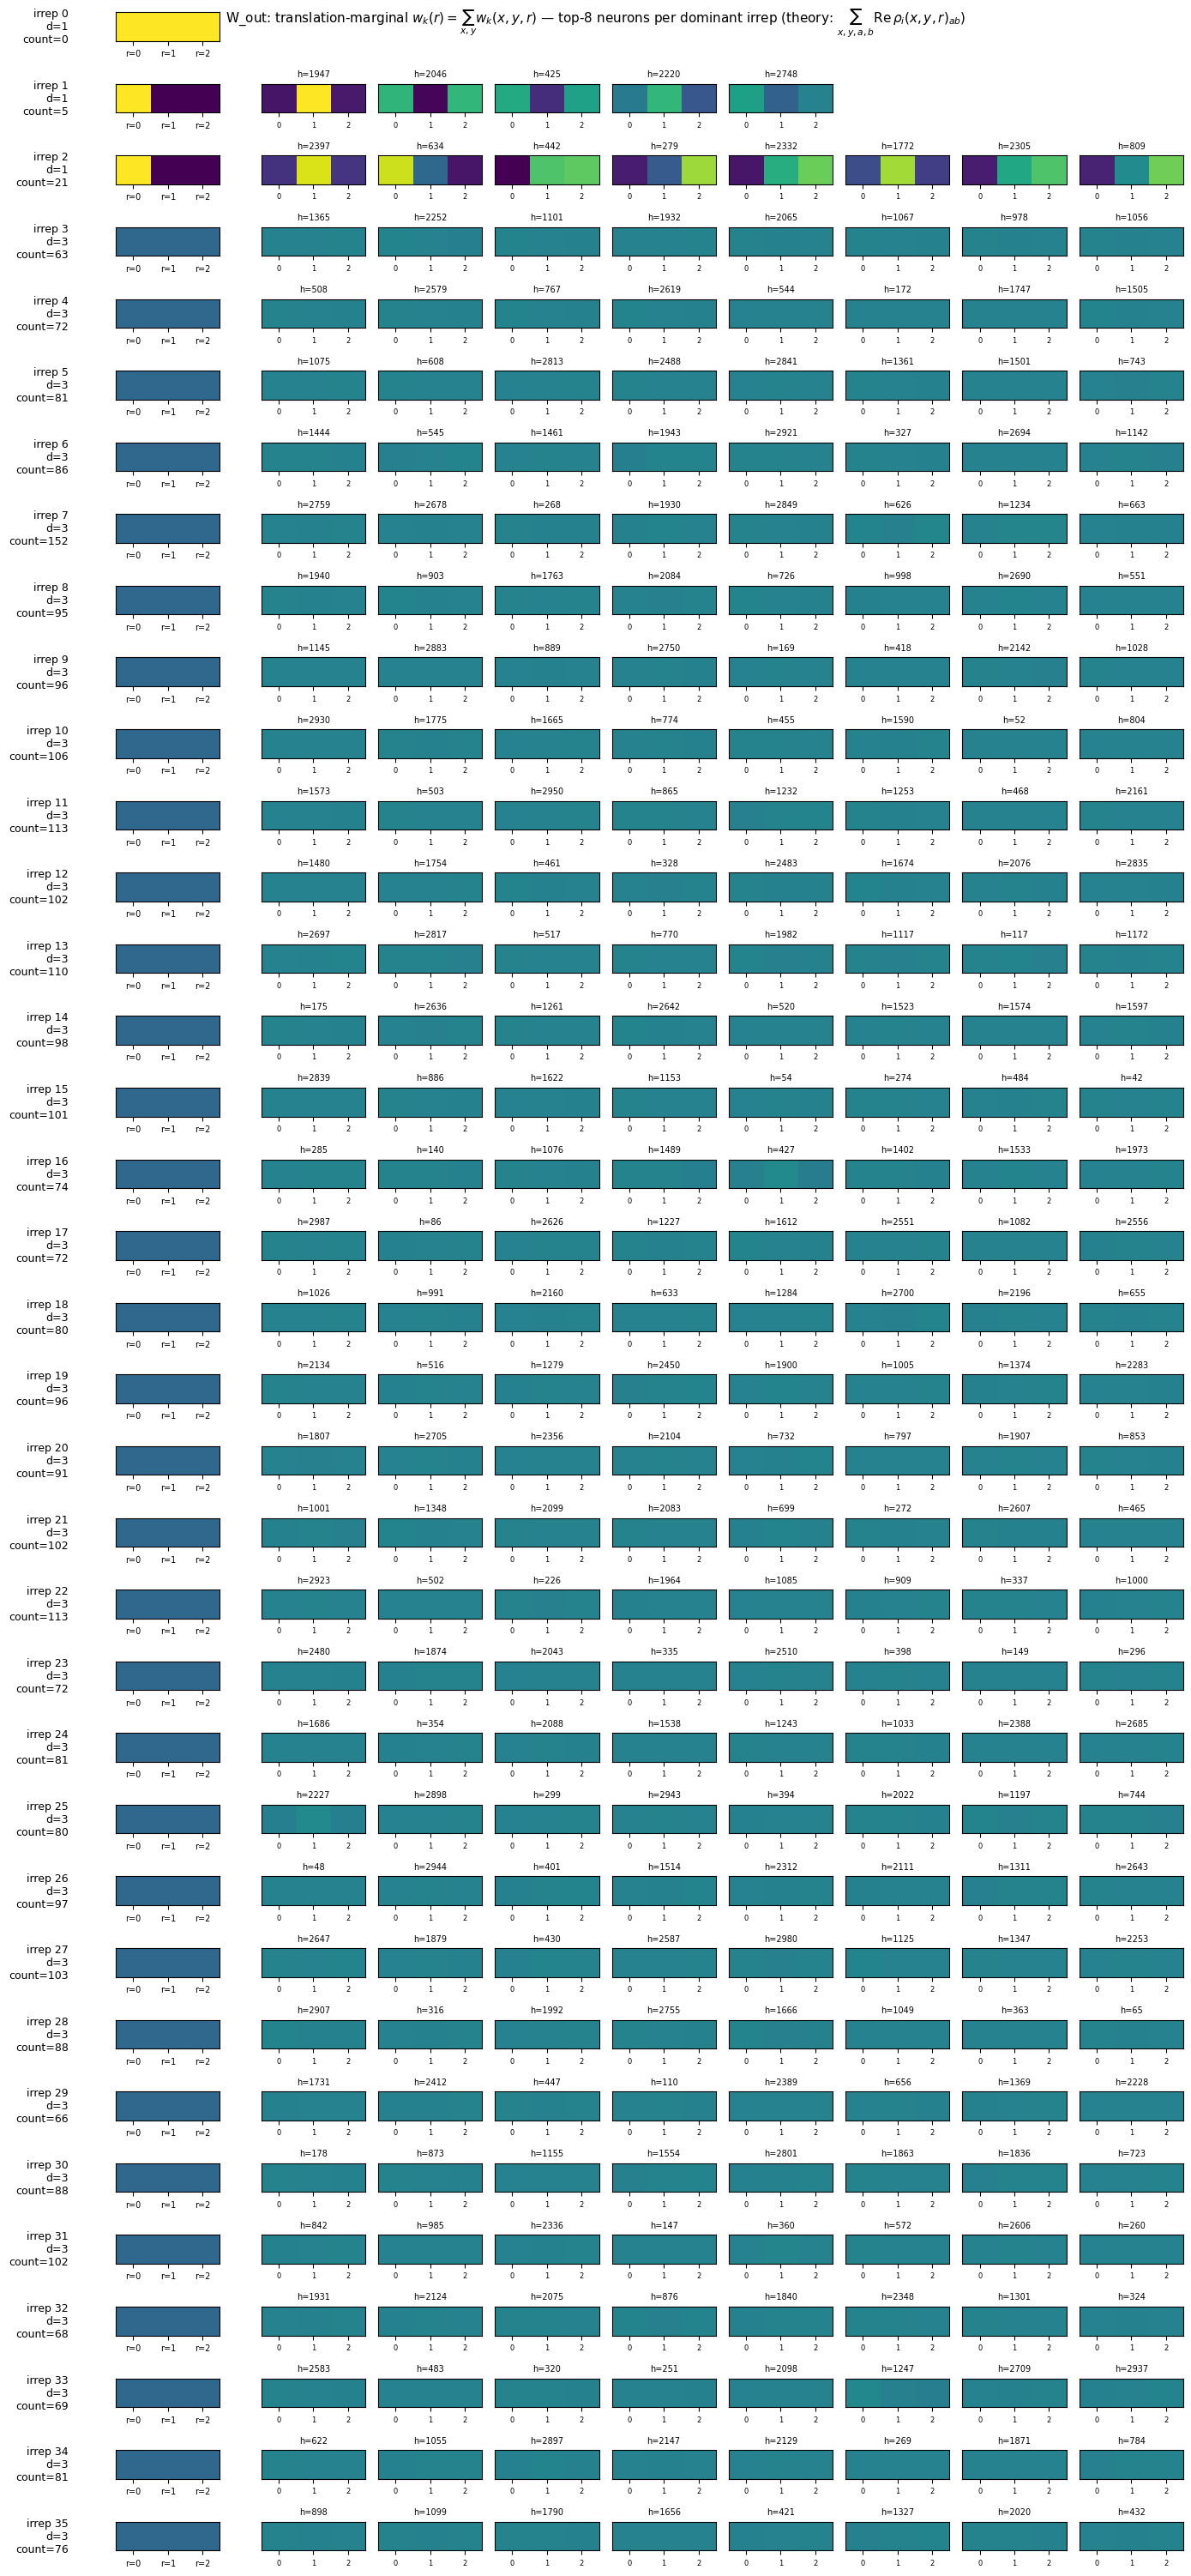

In [66]:
# === Translation-marginal display (analogous) ===
theory_vecs = np.stack([theory_trans_marg(ir) for ir in irreps])  # (n_irreps, m)

norm_n  = Normalize(vmin=neuron_vecs.min(), vmax=neuron_vecs.max())
norm_th = Normalize(vmin=theory_vecs.min(), vmax=theory_vecs.max())

nrows = len(irreps)
ncols = 2 + K_MAX
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(1.4 * ncols, 0.85 * nrows),
    squeeze=False,
    gridspec_kw={"width_ratios": [1.0, 0.15] + [1.0] * K_MAX},
)
for r, gid in enumerate(range(len(irreps))):
    ax_th = axes[r, 0]
    ax_th.imshow(theory_vecs[gid][None, :], cmap="viridis", norm=norm_th, aspect="auto")
    ax_th.set_xticks(range(m)); ax_th.set_xticklabels([f"r={i}" for i in range(m)], fontsize=7)
    ax_th.set_yticks([])
    ax_th.set_ylabel(f"irrep {gid}\nd={irreps[gid].dim}\ncount={counts[gid]}",
                     rotation=0, ha="right", va="center", labelpad=40, fontsize=9)
    axes[r, 1].axis("off")
    bucket = neurons_by_irrep[gid]
    for c in range(K_MAX):
        ax = axes[r, c + 2]
        if c < len(bucket):
            k = bucket[c]
            ax.imshow(neuron_vecs[k][None, :], cmap="viridis", norm=norm_n, aspect="auto")
            ax.set_title(f"h={k}", fontsize=7)
            ax.set_xticks(range(m)); ax.set_xticklabels([str(i) for i in range(m)], fontsize=6)
            ax.set_yticks([])
        else:
            ax.axis("off")
fig.suptitle(
    rf"{param}: translation-marginal $w_k(r) = \sum_{{x,y}} w_k(x,y,r)$ — top-{K_MAX} neurons per dominant irrep "
    rf"(theory: $\sum_{{x,y,a,b}}\mathrm{{Re}}\,\rho_i(x,y,r)_{{ab}}$)",
    fontsize=11,
)
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(f"{FIGURES_DIR}/{file_tag}_weights_by_irrep_trans.pdf", bbox_inches="tight")
plt.show()

### Slices

In [ ]:
def neuron_slices(w):
    """w(x,y,r) -> (n, m*n): the m rotation slices laid out left-to-right."""
    return np.concatenate(list(w.reshape(m, n, n)), axis=1)


def theory_slices(irrep):
    """chi_i(x,y,r) sliced the same way; basis-invariant."""
    M = _irrep_full(irrep)                          # (|G|, d, d) — helper from earlier
    chi = np.trace(M, axis1=-2, axis2=-1).real     # (|G|,)
    return np.concatenate(list(chi.reshape(m, n, n)), axis=1)


neuron_sl = np.stack([neuron_slices(W_all[:, k]) for k in range(n_neurons)])  # (H, n, m*n)
theory_sl = [theory_slices(ir) for ir in irreps]                              # list of (n, m*n)

norm_n  = Normalize(vmin=neuron_sl.min(), vmax=neuron_sl.max())
norm_th = Normalize(vmin=min(t.min() for t in theory_sl),
                    vmax=max(t.max() for t in theory_sl))


def _draw_tile(ax, img, norm, title=None):
    ax.imshow(img, cmap="RdBu_r", norm=norm, origin="lower", aspect="equal")
    for k_ in range(1, m):
        ax.axvline(k_ * n - 0.5, color="black", lw=0.6)   # rotation-slice separators
    ax.set_xticks([n // 2 + i * n for i in range(m)])
    ax.set_xticklabels([f"r={i}" for i in range(m)], fontsize=6)
    ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=7)


nrows = len(irreps)
ncols = 2 + K_MAX
# tiles are now m times wider than tall, so widen the figure accordingly
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(0.9 * m * ncols, 1.1 * nrows),
    squeeze=False,
    gridspec_kw={"width_ratios": [1.0, 0.15] + [1.0] * K_MAX},
)
for r, gid in enumerate(range(len(irreps))):
    _draw_tile(axes[r, 0], theory_sl[gid], norm_th)
    axes[r, 0].set_ylabel(f"irrep {gid}\nd={irreps[gid].dim}\ncount={counts[gid]}",
                          rotation=0, ha="right", va="center", labelpad=40, fontsize=9)
    axes[r, 1].axis("off")
    bucket = neurons_by_irrep[gid]
    for c in range(K_MAX):
        ax = axes[r, c + 2]
        if c < len(bucket):
            _draw_tile(ax, neuron_sl[bucket[c]], norm_n, title=f"h={bucket[c]}")
        else:
            ax.axis("off")

fig.suptitle(
    rf"{param}: rotation-sliced $w_k(\cdot, \cdot, r)$ for $r=0,\ldots,{m-1}$  —  "
    rf"top-{K_MAX} neurons per dominant irrep   (theory: $\mathrm{{Re}}\,\chi_i(\cdot, \cdot, r)$)",
    fontsize=11,
)
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(f"{FIGURES_DIR}/{file_tag}_weights_by_irrep_slices.pdf", bbox_inches="tight")
plt.show()

NameError: name 'np' is not defined